*© 2026 Paul Fergus*

# Lab 2 — Your first deep learning model in PyTorch

**Module:** 7144COMP — Deep Learning Concepts and Techniques  
**Week:** 2  
**Estimated time:** 120 minutes

---

## Learning outcomes

By the end of this lab you should be able to:

1. Load and explore a real medical classification dataset using scikit-learn and pandas.
2. Apply MinMax scaling correctly — fitting on the training set only and explaining *why*.
3. Build a feedforward neural network in PyTorch by subclassing `nn.Module`.
4. Wrap data in a `Dataset` and a `DataLoader` for proper mini-batch training.
5. Write a training loop by hand: forward pass, loss, `backward()`, optimizer step.
6. Implement early stopping, and explain why it matters for generalisation.
7. Evaluate a binary classifier with accuracy, precision, recall, and a confusion matrix — and justify which metric matters most in a medical screening context.

## Prerequisites

- **Lab 1** completed — you've built an MLP by hand and understand forward and backward propagation.
- The textbook *Applied Deep Learning* (Fergus & Chalmers), Chapter 2 — feedforward networks and gradient descent.
- Lecture 2: *From the math to the framework — autograd, optimizers, and the training loop*.

## The thread from last week

In Lab 1 you wrote a multi-layer perceptron from scratch: forward pass, backpropagation, weight updates. You understand exactly what happens inside a neural network. This week we promote that understanding into a real deep learning framework. **PyTorch does the autograd for you, but every other step is still yours to see.** You will write the training loop. You will compute the loss. You will call `optimizer.step()`. PyTorch just handles the calculus.

By the end of this lab, you'll have built a network that achieves around 97% accuracy on a real medical classification task with about 60 lines of model and training code.

## Useful references

- [PyTorch documentation](https://pytorch.org/docs/stable/index.html) — bookmark this; you'll live here.
- [Breast Cancer Wisconsin (Diagnostic) dataset on the UCI archive](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic).
- Street, W.N., Wolberg, W.H. and Mangasarian, O.L. (1993). *Nuclear feature extraction for breast tumor diagnosis*. IS&T/SPIE 1993 International Symposium on Electronic Imaging.

---

## 1. The dataset

We will use the **Breast Cancer Wisconsin (Diagnostic) dataset**, one of the most-cited datasets in classification research. The 569 samples are derived from digitised fine-needle aspirate (FNA) images of breast masses, with each sample described by 30 numeric features capturing characteristics of the cell nuclei (radius, texture, perimeter, area, smoothness, etc., in mean, standard error, and 'worst' variants).

Each sample is labelled as either **malignant** (212 samples) or **benign** (357 samples). Our task is to train a neural network to distinguish them.

> **Why this dataset?** It's small enough to train quickly without a GPU, large enough to be non-trivial, comes pre-cleaned, and represents a problem where getting predictions right matters: a missed malignancy has real consequences. We will return to that point when we evaluate the model.

We load it directly from scikit-learn — no external file download needed. The container is fully self-contained.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Reproducibility — set every seed we can. Important for marking and debugging.
RNG_SEED = 7144
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)

# Use the GPU if available, otherwise fall back to CPU.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")

PyTorch version: 2.11.0+cu128
Device: cuda


In [2]:
# Load the dataset and turn it into a DataFrame for easier exploration.
data = load_breast_cancer(as_frame=True)
df = data.frame                              # the features and target combined
df = df.rename(columns={"target": "label"})

# In sklearn's encoding, 0 = malignant, 1 = benign. We keep that convention
# but it's good to be explicit so it doesn't bite us in the evaluation phase.
print(f"Shape: {df.shape}")
print(f"Label encoding: 0 = malignant, 1 = benign")
df.head()

Shape: (569, 31)
Label encoding: 0 = malignant, 1 = benign


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2. Exploratory data analysis (EDA)

**Never go straight from `read_csv` to `model.fit`.** Look at your data first. EDA is the cheapest insurance policy in machine learning: every hour you spend understanding the dataset saves several hours later trying to debug strange model behaviour.

We will check three things in this lab:

1. **Class balance** — are the two classes roughly equal, or is one much more common?
2. **Feature correlations** — are some features essentially measuring the same thing?
3. **Feature-to-target correlations** — which features carry the most signal about the label?

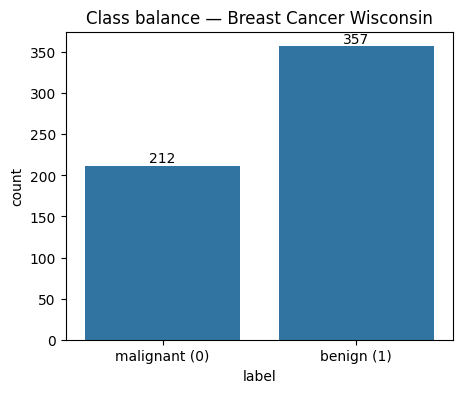


Class distribution: {1: 357, 0: 212}
Imbalance ratio: 0.59


In [3]:
# Class balance
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="label", data=df, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["malignant (0)", "benign (1)"])
ax.set_title("Class balance — Breast Cancer Wisconsin")
ax.set_ylabel("count")
ax.bar_label(ax.containers[0])
plt.show()

print(f"\nClass distribution: {dict(df['label'].value_counts())}")
print(f"Imbalance ratio: {df['label'].value_counts().min() / df['label'].value_counts().max():.2f}")

**What to observe.** The dataset is *slightly* imbalanced — about 63% benign, 37% malignant. Not severe (we wouldn't expect a class-imbalance technique like SMOTE to be needed), but worth being aware of. A model that always predicted 'benign' would get 63% accuracy and be useless clinically. That is the first reason **accuracy alone is not the right metric for this problem**.

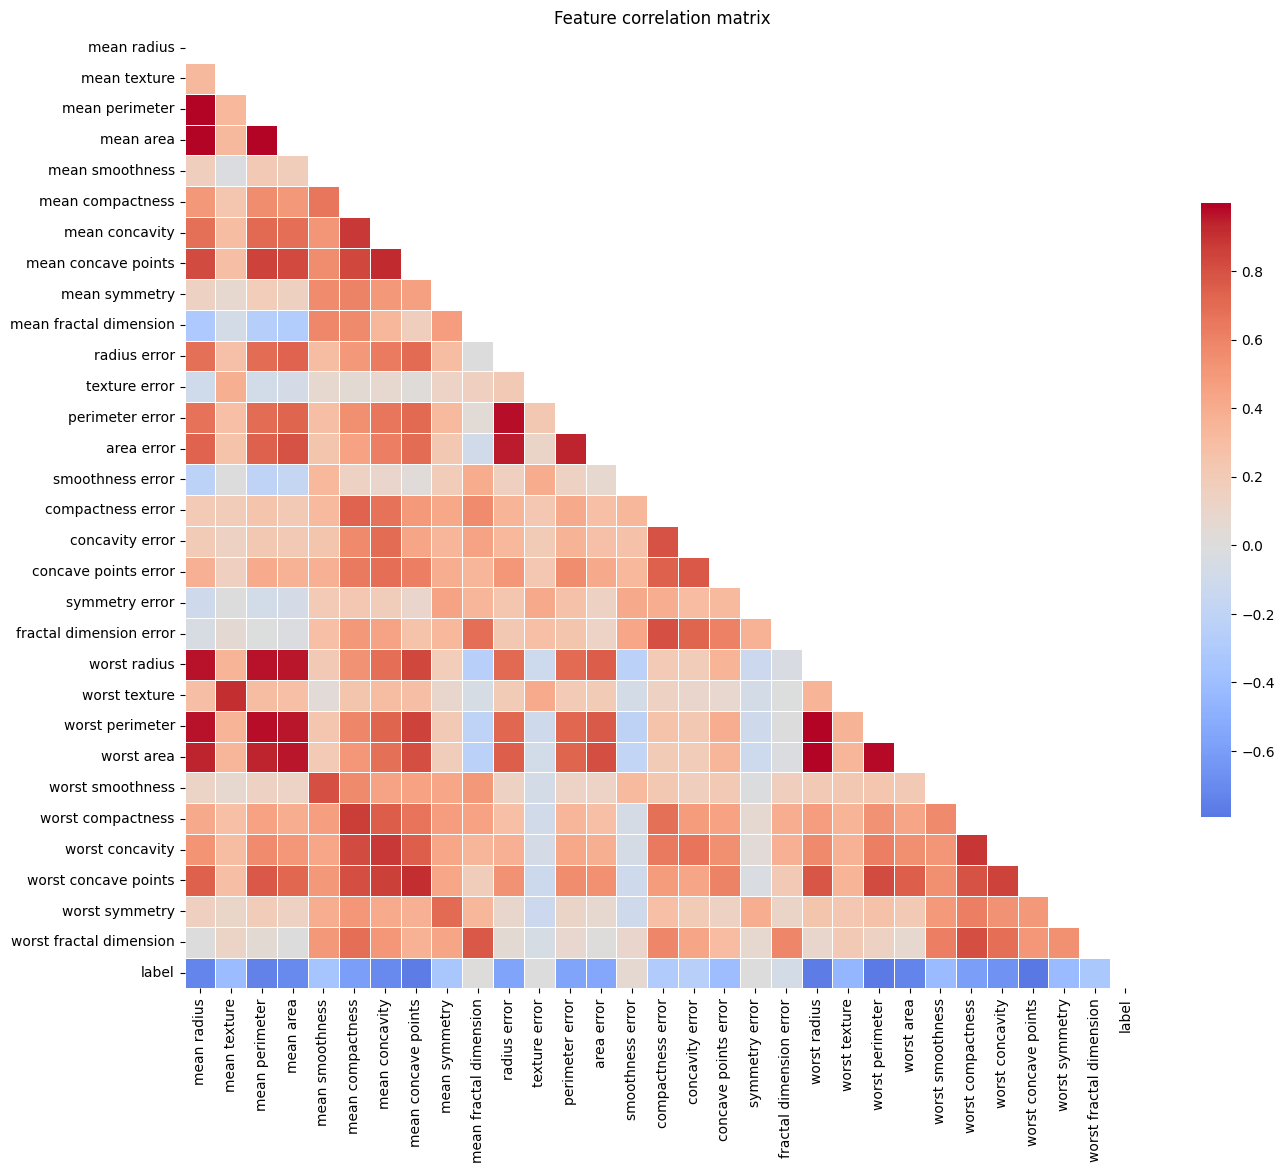

In [4]:
# Feature correlation heatmap (lower triangle only — the upper mirror adds nothing).
fig, ax = plt.subplots(figsize=(14, 12))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=False, mask=mask, cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

**What to observe.** You'll see bright red blocks indicating heavy positive correlation between groups of features — for example, `mean radius`, `mean perimeter`, and `mean area` are almost perfectly correlated (which makes geometric sense: bigger radius implies bigger perimeter and area). Heavily-correlated features carry redundant information.

**Should we drop them?** In classical statistics (linear regression, logistic regression) we often would, because correlated predictors inflate coefficient variance. For neural networks the answer is more nuanced — networks can usually handle correlated inputs without trouble, and dropping features means losing any unique signal they contain. We will keep all 30 features for now, but Exercise 1(c) revisits this.

Now the most useful single view — how each feature correlates with the *target*:

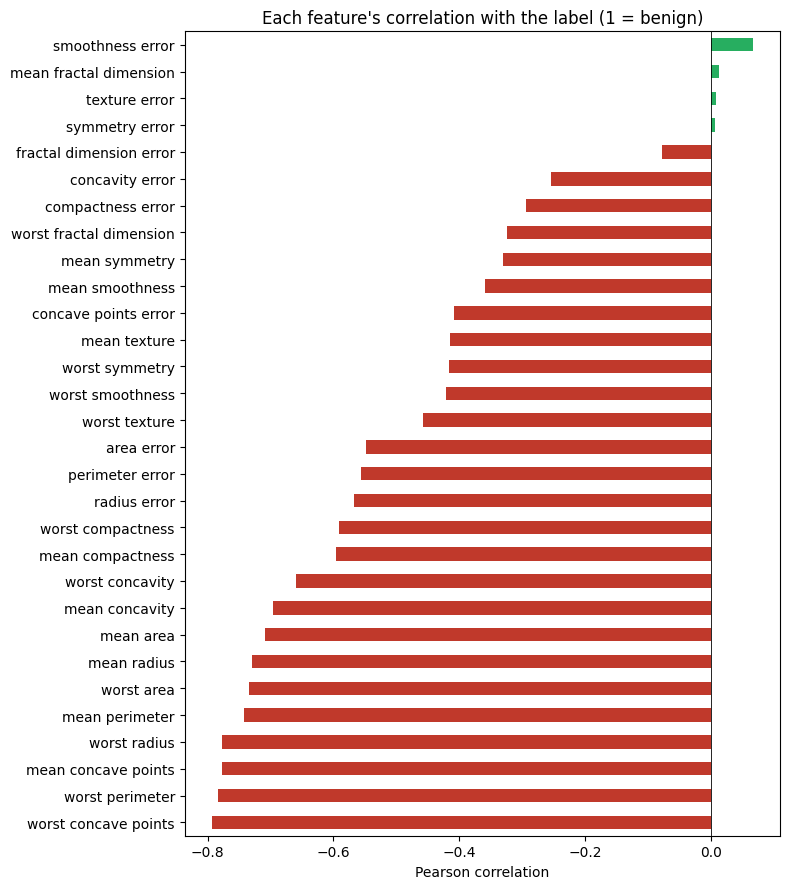

Top 5 most informative features (by |correlation|):
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636


In [5]:
# Correlation with the target, sorted from most negative to most positive.
target_corr = df.corr()["label"].drop("label").sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
colors = ["#c0392b" if v < 0 else "#27ae60" for v in target_corr.values]
target_corr.plot(kind="barh", color=colors, ax=ax)
ax.axvline(0, color="black", linewidth=0.6)
ax.set_title("Each feature's correlation with the label (1 = benign)")
ax.set_xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

print("Top 5 most informative features (by |correlation|):")
print(target_corr.abs().sort_values(ascending=False).head().to_string())

**What to observe.** Many features have strong negative correlation with the label (`mean concave points`, `worst concave points`, `mean perimeter`, etc.). Remember: label `1` is *benign* — so a *negative* correlation means "larger value of this feature → more likely to be malignant." Tumour size and irregularity features are the strongest signals, which matches medical intuition. A neural network will learn these relationships automatically, but it's reassuring to see they exist.

## 3. Train/test split and scaling

Two operations, in this order:

1. **Split first.** We hold out 25% of the data as a test set we won't touch until the very end.
2. **Scale second.** We fit the scaler **on the training set only**, then transform both train and test.

**Why this order matters.** If we scaled before splitting, the scaler would 'see' the test data's min and max values, leaking information about the test set into the training pipeline. The model's reported test performance would then be optimistic — it would have benefited from peeking at the test distribution. This is a classic and easy mistake; you will encounter it in real codebases.

**Why scale at all?** Neural networks train with gradient descent, and the loss surface is friendlier when all features are on comparable scales. A feature that ranges from 0 to 2500 (like `area`) would otherwise dominate the gradient over a feature that ranges from 0 to 0.5 (like `smoothness`).

In [6]:
X = df.drop("label", axis=1).values.astype(np.float32)
y = df["label"].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RNG_SEED,
    stratify=y,            # preserve the class balance in both splits
)

# Fit on train ONLY.
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

print(f"Train: {X_train.shape}, positives: {int(y_train.sum())}, negatives: {int(len(y_train) - y_train.sum())}")
print(f"Test:  {X_test.shape},  positives: {int(y_test.sum())},  negatives: {int(len(y_test) - y_test.sum())}")

Train: (426, 30), positives: 267, negatives: 159
Test:  (143, 30),  positives: 90,  negatives: 53


## 4. Tensors, Datasets, and DataLoaders

PyTorch operates on **tensors** — think of them as NumPy arrays with two superpowers:

1. They can live on a **GPU** for fast parallel computation.
2. They can record an **autograd graph** so PyTorch can compute gradients automatically.

Then PyTorch provides two abstractions for getting data *into* the model:

- A **`Dataset`** wraps your raw data and tells PyTorch how to fetch one sample.
- A **`DataLoader`** wraps a Dataset and handles batching, shuffling, and parallel loading.

For our 569-sample dataset, batching isn't strictly necessary — we could pass the whole training set in one go. But every real dataset is too big for that, so we set up the proper pattern now.

In [7]:
class TabularDataset(Dataset):
    """A minimal Dataset that wraps two NumPy arrays (features, labels)."""

    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float().unsqueeze(1)   # shape (N, 1) for BCE loss

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_ds = TabularDataset(X_train, y_train)
test_ds = TabularDataset(X_test, y_test)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Inspect a single batch — always a good sanity check.
xb, yb = next(iter(train_loader))
print(f"One batch — features: {xb.shape} ({xb.dtype}), labels: {yb.shape} ({yb.dtype})")
print(f"Batches per epoch: {len(train_loader)} (train), {len(test_loader)} (test)")

One batch — features: torch.Size([32, 30]) (torch.float32), labels: torch.Size([32, 1]) (torch.float32)
Batches per epoch: 14 (train), 5 (test)


## 5. Building the model

We define our network as a subclass of `nn.Module`. This is the canonical PyTorch pattern: define your layers in `__init__`, then describe how the forward pass flows through them in `forward()`.

The architecture mirrors the original lab so you can compare against last week's from-scratch MLP:

- **Input layer**: 30 features (one per column of our preprocessed data)
- **Hidden layer 1**: 30 units, ReLU activation, dropout 0.3
- **Hidden layer 2**: 15 units, ReLU activation, dropout 0.3
- **Output layer**: 1 unit — *no* activation (we'll explain why below)

**Why no sigmoid at the end?** Because we will use `BCEWithLogitsLoss` for training, which is mathematically equivalent to `Sigmoid → BCELoss` but numerically more stable (it uses the log-sum-exp trick internally to avoid floating-point overflow). The model outputs **logits**; we apply the sigmoid manually when we want probabilities for evaluation.

In [8]:
class BinaryClassifier(nn.Module):
    """A small feedforward network for binary classification.

    Parameters
    ----------
    n_features : int
        Number of input features.
    hidden_sizes : tuple[int, ...]
        Sizes of the hidden layers, in order.
    dropout : float
        Dropout probability applied after each hidden layer.
    """

    def __init__(self, n_features: int, hidden_sizes=(30, 15), dropout: float = 0.3):
        super().__init__()
        layers = []
        in_dim = n_features
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))     # final logit, no activation here
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model = BinaryClassifier(n_features=X_train.shape[1]).to(DEVICE)
print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")

BinaryClassifier(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=30, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=30, out_features=15, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=15, out_features=1, bias=True)
  )
)

Trainable parameters: 1,411


**Quick comparison to Lab 1.** Last week's from-scratch MLP had a few dozen parameters. This model has well over a thousand — and it took us five lines to define rather than a hundred. Frameworks earn their keep at the architectural level: you compose, they handle the bookkeeping.

## 6. The training loop

This is the heart of the lab. In Keras you would write `model.fit(X, y, epochs=100)` and the framework would hide everything. In PyTorch, the loop is yours — and seeing it explicitly will save you hours when something goes wrong later.

Every training loop has the same five steps inside the inner `for batch in loader` block:

1. **Forward pass** — push the batch through the model.
2. **Loss** — compare predictions to targets.
3. **Zero the gradients** — PyTorch *accumulates* gradients by default, so we clear them each step.
4. **Backward pass** — `loss.backward()` computes all the gradients for us (this is what we did by hand in Lab 1).
5. **Optimizer step** — apply the gradients to update the weights.

We will also implement an **`EarlyStopping`** helper that tracks the validation loss and stops training when it stops improving. This mirrors Keras's `EarlyStopping(restore_best_weights=True)`.

In [9]:
class EarlyStopping:
    """Stop training when a monitored metric has stopped improving.

    Parameters
    ----------
    patience : int
        Number of epochs with no improvement after which training stops.
    min_delta : float
        Minimum change in the monitored value to count as an improvement.
    """

    def __init__(self, patience: int = 25, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.epochs_without_improvement = 0
        self.best_state = None
        self.should_stop = False

    def step(self, current_loss: float, model: nn.Module) -> None:
        if current_loss < self.best_loss - self.min_delta:
            # New best — remember the weights and reset the patience counter.
            self.best_loss = current_loss
            self.epochs_without_improvement = 0
            self.best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            self.epochs_without_improvement += 1
            if self.epochs_without_improvement >= self.patience:
                self.should_stop = True

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [10]:
def run_epoch(model, loader, criterion, optimizer=None):
    """Run one epoch of training or evaluation.

    If `optimizer` is provided, we are in training mode (we backprop and step).
    If it is None, we are in evaluation mode (no gradients, no weight updates).
    Returns the average loss and accuracy across the epoch.
    """
    is_train = optimizer is not None
    model.train(mode=is_train)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            # 1. Forward pass
            logits = model(xb)
            # 2. Loss
            loss = criterion(logits, yb)

            if is_train:
                # 3. Zero gradients
                optimizer.zero_grad()
                # 4. Backward pass — this is what we did by hand in Lab 1.
                loss.backward()
                # 5. Optimizer step
                optimizer.step()

            # Accumulate metrics
            batch_size = xb.size(0)
            total_loss += loss.item() * batch_size
            preds = (torch.sigmoid(logits) > 0.5).float()
            total_correct += (preds == yb).sum().item()
            total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples

In [11]:
# Re-initialise the model so this cell is re-runnable.
torch.manual_seed(RNG_SEED)
model = BinaryClassifier(n_features=X_train.shape[1]).to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
early_stopping = EarlyStopping(patience=25)

MAX_EPOCHS = 200
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, test_loader, criterion, optimizer=None)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if epoch == 1 or epoch % 10 == 0:
        print(f"epoch {epoch:>3d}  |  train loss {train_loss:.4f} acc {train_acc:.3f}  |  "
              f"val loss {val_loss:.4f} acc {val_acc:.3f}")

    early_stopping.step(val_loss, model)
    if early_stopping.should_stop:
        print(f"\nEarly stopping at epoch {epoch}. Best val loss: {early_stopping.best_loss:.4f}")
        break

# Restore the best-performing weights — this is the model we'll evaluate.
early_stopping.restore_best(model)
print("Restored best weights.")

epoch   1  |  train loss 0.7074 acc 0.369  |  val loss 0.6959 acc 0.371
epoch  10  |  train loss 0.4347 acc 0.878  |  val loss 0.3973 acc 0.888
epoch  20  |  train loss 0.1973 acc 0.937  |  val loss 0.1892 acc 0.902
epoch  30  |  train loss 0.1746 acc 0.934  |  val loss 0.1387 acc 0.937
epoch  40  |  train loss 0.1490 acc 0.946  |  val loss 0.1030 acc 0.972
epoch  50  |  train loss 0.1132 acc 0.962  |  val loss 0.0813 acc 0.979
epoch  60  |  train loss 0.1032 acc 0.965  |  val loss 0.0677 acc 0.979
epoch  70  |  train loss 0.0954 acc 0.965  |  val loss 0.0600 acc 0.979
epoch  80  |  train loss 0.0948 acc 0.974  |  val loss 0.0515 acc 0.979
epoch  90  |  train loss 0.0925 acc 0.974  |  val loss 0.0473 acc 0.986
epoch 100  |  train loss 0.0695 acc 0.969  |  val loss 0.0435 acc 0.986
epoch 110  |  train loss 0.0778 acc 0.981  |  val loss 0.0412 acc 0.986
epoch 120  |  train loss 0.0794 acc 0.977  |  val loss 0.0455 acc 0.979
epoch 130  |  train loss 0.0727 acc 0.979  |  val loss 0.0381 ac

**Note on the test set as a validation set.** Strictly speaking, you should hold out a *separate* validation set for early stopping, and only touch the test set once at the very end. Using the test set as a validation signal makes our reported test performance slightly optimistic. For this small dataset and teaching context we accept the simplification, but in real work you would do a three-way split (train / val / test) or use cross-validation. We will properly separate them in Lab 3.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="validation")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE loss"); axes[0].set_title("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="validation")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].set_title("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Evaluation — and a bug worth telling you about

Before we look at the results, a word of caution. **The original version of this lab had the following evaluation code:**

```python
predict_x = model.predict(X_test)
predictions = np.argmax(predict_x, axis=1)    # ← BUG
```

That second line is wrong. Our network has *one* output unit (a sigmoid probability). `argmax` over a one-column array always returns 0. The 'classification report' the original lab produced was therefore measuring nothing — it just reported the class balance.

**The correct thing to do** for a binary classifier with a single output is to threshold the sigmoid output at 0.5:

```python
logits = model(X_test_tensor)
probs = torch.sigmoid(logits)
predictions = (probs > 0.5).long()
```

`argmax` is the right move for a *multi-class* classifier with one output per class (e.g. 10 outputs for MNIST digits). The bug was a copy-paste from a multi-class example. **Spotting this kind of pattern-mismatch is a key practical skill** — you'll see this exact bug in the wild more often than you'd like.

In [ ]:
# Run the trained model over the test set, properly this time.
model.eval()
all_probs = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(DEVICE)
        all_probs.append(torch.sigmoid(model(xb)).cpu().numpy())

y_prob = np.concatenate(all_probs).ravel()
y_pred = (y_prob > 0.5).astype(int)

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification report (0 = malignant, 1 = benign):")
print(classification_report(y_test, y_pred, target_names=["malignant", "benign"]))

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["malignant", "benign"],
            yticklabels=["malignant", "benign"], ax=ax)
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title("Confusion matrix")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True negatives (correctly identified malignant): {tn}")
print(f"False positives (benign called malignant):       {fp}")
print(f"False negatives (malignant called benign):       {fn}   ← the dangerous one")
print(f"True positives (correctly identified benign):    {tp}")

## 8. Why precision and recall matter more than accuracy here

If our model achieves, say, 97% accuracy, that sounds excellent. But **for a medical screening tool, the kinds of mistakes matter more than the total number of mistakes.**

- A **false positive** (predicting malignant when it's actually benign) sends a patient for additional, possibly invasive testing they didn't need. Stressful, costly, but recoverable.
- A **false negative** (predicting benign when it's actually malignant) means a missed cancer. The patient goes home reassured, and the disease progresses untreated.

These two errors are *not* symmetric in the real world. For a screening tool we typically want **high recall on the malignant class** even at the cost of some false positives. The classification report above shows precision and recall *per class*, so you can read off both quantities directly.

> This is the difference between *classification* (a maths problem) and *applied machine learning* (a problem with people on the receiving end). You will revisit this distinction often in this module.

> **Note on the result.** This dataset is unusually clean and the two classes are highly separable in feature space, so we get near-perfect performance. Don't take ~99% as a benchmark to aim for on every problem — most real datasets are messier, and accuracies in the 70s or 80s can be excellent in practice. The point of the medical framing above is the *kinds* of errors, not the raw numbers.

---

## 9. Exercise 1 — architecture

Do **all three** of the following. For each, train the modified model, plot the loss curves, and record the test accuracy. Then write a short markdown reflection.

**(a)** Train a version with **no dropout** (`dropout=0.0`). What happens to the gap between train and validation loss? What is this called?

**(b)** Train a version with **much heavier dropout** (`dropout=0.7`). Does the model train at all? Why might high dropout hurt this particular small network?

**(c)** Train a **deeper, wider** network: try `hidden_sizes=(64, 32, 16)` and `dropout=0.3`. Does the extra capacity help, hurt, or make no difference on this dataset? Explain *why* in terms of the dataset's size.

In [ ]:
# Your code for Exercise 1 (a), (b), (c) here.


*Your written observations for Exercise 1:*

(a) 

(b) 

(c) 

## 10. Exercise 2 — training dynamics

Do **all three** of the following.

**(a)** Skip the MinMax scaling entirely (use the raw `X_train` and `X_test` directly) and train the original model. Does training still converge? How does the loss curve change? Why?

**(b)** Swap the optimizer from `Adam` to `SGD` (with `lr=0.01`, since SGD usually needs a higher learning rate than Adam on the same problem). Train for the same number of max epochs. Which optimizer reaches lower validation loss? Which is more sensitive to the learning rate?

**(c)** Try `BATCH_SIZE = 8` and `BATCH_SIZE = 256`. How does the choice of batch size affect (i) how long each epoch takes, (ii) the smoothness of the loss curve, and (iii) the final test accuracy?

In [ ]:
# Your code for Exercise 2 (a), (b), (c) here.


*Your written observations for Exercise 2:*

(a) 

(b) 

(c) 

## 11. Exercise 3 — evaluation in depth

Do **all three** of the following.

**(a) Compute precision and recall by hand.** Given the four numbers `tn, fp, fn, tp` printed above, compute the precision and recall for the **malignant** class directly from the formulas:

$$\text{precision} = \frac{TP}{TP + FP} \qquad \text{recall} = \frac{TP}{TP + FN}$$

*Be careful:* in scikit-learn's report, 'malignant' is class 0, so what counts as 'positive' is reversed from the convention above. State your reasoning clearly. Confirm your numbers match scikit-learn's `classification_report`.

**(b) Examine the misclassified examples.** Find the row indices in the test set where `y_pred != y_test`. For each misclassified example, print its predicted probability. Are the model's mistakes confident (probability near 0 or 1) or uncertain (probability near 0.5)? What does that tell you about the model's calibration?

**(c) Threshold sweep.** Instead of using 0.5 as the decision threshold, try a range of thresholds from 0.1 to 0.9 in steps of 0.05. For each, compute and plot: (i) precision for the malignant class, (ii) recall for the malignant class. At what threshold would you operate this model if you were *deploying it as a screening tool where false negatives are extremely costly*?

In [ ]:
# Your code for Exercise 3 (a), (b), (c) here.


*Your written observations for Exercise 3:*

(a) 

(b) 

(c) 

---

## 12. Reflection questions

Answer in the markdown cells below. Aim for 2–4 sentences per question.

**Q1.** In Lab 1 you wrote forward propagation, backpropagation, and weight updates by hand. In this lab, which of those three steps did PyTorch do for you, and which one are you still responsible for writing?

**Q2.** Explain why we fit the MinMax scaler on the training set only, and not on the full dataset before splitting. What is the name for the failure mode this avoids, and where else in machine learning does it crop up?

**Q3.** The original version of this lab used `np.argmax` to derive predictions from a single-sigmoid-output network, which silently produced meaningless results. Describe one practical strategy you could use during a project to catch this kind of silent failure before it ends up in your final report.

**Q4.** Our `BCEWithLogitsLoss` is mathematically equivalent to `Sigmoid → BCELoss`, but PyTorch recommends the former for numerical stability. In your own words, explain what numerical stability means here and why a 'mathematically equivalent' implementation might still be a bad idea in floating-point arithmetic.

**Q5.** Suppose you were asked to deploy this model in a real hospital. Name **two** ethical or practical concerns you would raise *beyond* the technical question of accuracy.

*Your answers:*

**A1.** 

**A2.** 

**A3.** 

**A4.** 

**A5.** 

---

## What's next

In **Lab 3** we will move from binary classification to **multi-class classification**, and tackle the train/validation/test split properly. We'll also meet our first image dataset, where the feature engineering effort we did in this lab is replaced by something much more interesting: convolutions.

Before leaving today, make sure:

- [ ] You have completed Exercises 1, 2, and 3
- [ ] You have answered the reflection questions
- [ ] Your notebook runs **top to bottom without errors** (*Kernel → Restart and Run All*)
- [ ] You have saved your work — the `labs/` folder is volume-mounted, so your edits persist on your host machine outside the container